# Global Solution 2026 — Análise Interativa e Escala de Decisão
**FIAP — Estruturas de Dados e Algoritmos**

Este notebook complementa o relatório com análises interativas dos dois cenários brasileiros e a escala de decisão fundamentada.

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import math
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from src.data_structures import Grafo, BinarySearchTree
from src.brute_force import forca_bruta_caminhos, dados_explosao_combinatoria
from src.greedy import dijkstra, prim, kruskal, reconstruir_caminho
from src.performance_monitor import PerformanceMonitor, gerar_grafo_sintetico
from src.visualizations import *

print('Módulos carregados com sucesso!')

Módulos carregados com sucesso!


## 1. Cenário A — Enchentes RS

In [2]:
g_rs = Grafo.from_json('../data/raw/municipios_rs.json')
bst_rs = BinarySearchTree.from_grafo(g_rs)
print(g_rs)
print(bst_rs)
print(f'Municípios em ordem de risco (in-order BST):')
for v in bst_rs.percurso_in_order():
    print(f'  {v[1]:<25} risco={v[2]:.2f}')

Grafo(V=15, E=20)
BinarySearchTree(n=15, altura=6)
Municípios em ordem de risco (in-order BST):
  Passo Fundo               risco=0.55
  Caxias do Sul             risco=0.58
  Santa Maria               risco=0.61
  Rio Grande                risco=0.66
  Viamao                    risco=0.68
  Porto Alegre              risco=0.72
  Pelotas                   risco=0.73
  Gravataí                  risco=0.76
  Montenegro                risco=0.78
  Sapucaia do Sul           risco=0.79
  Alvorada                  risco=0.82
  Novo Hamburgo             risco=0.85
  Canoas                    risco=0.88
  Sao Leopoldo              risco=0.91
  Lajeado                   risco=0.95


In [3]:
# Dijkstra a partir de Porto Alegre
PORTO_ALEGRE = 4314902
res = dijkstra(g_rs, PORTO_ALEGRE, bst=bst_rs, limiar_risco=0.80)

print('Custos mínimos (Porto Alegre → cada município):')
for vid, custo in sorted(res.custos_acumulados.items(), key=lambda x: x[1]):
    v = g_rs.get_vertice(vid)
    cam = reconstruir_caminho(res, vid)
    print(f'  {v[1]:<22} custo={custo:.2f}h  risco={v[2]:.2f}  passos={len(cam)-1}')

Custos mínimos (Porto Alegre → cada município):
  Porto Alegre           custo=0.00h  risco=0.72  passos=0
  Alvorada               custo=0.40h  risco=0.82  passos=1
  Canoas                 custo=0.50h  risco=0.88  passos=1
  Sapucaia do Sul        custo=0.80h  risco=0.79  passos=2
  Gravataí               custo=0.80h  risco=0.76  passos=1
  Viamao                 custo=0.90h  risco=0.68  passos=1
  Sao Leopoldo           custo=1.00h  risco=0.91  passos=2
  Novo Hamburgo          custo=1.60h  risco=0.85  passos=3
  Montenegro             custo=1.90h  risco=0.78  passos=2
  Lajeado                custo=2.20h  risco=0.95  passos=3
  Caxias do Sul          custo=2.60h  risco=0.58  passos=2
  Pelotas                custo=3.20h  risco=0.73  passos=1
  Santa Maria            custo=4.70h  risco=0.61  passos=4
  Rio Grande             custo=4.70h  risco=0.66  passos=2
  Passo Fundo            custo=5.70h  risco=0.55  passos=3


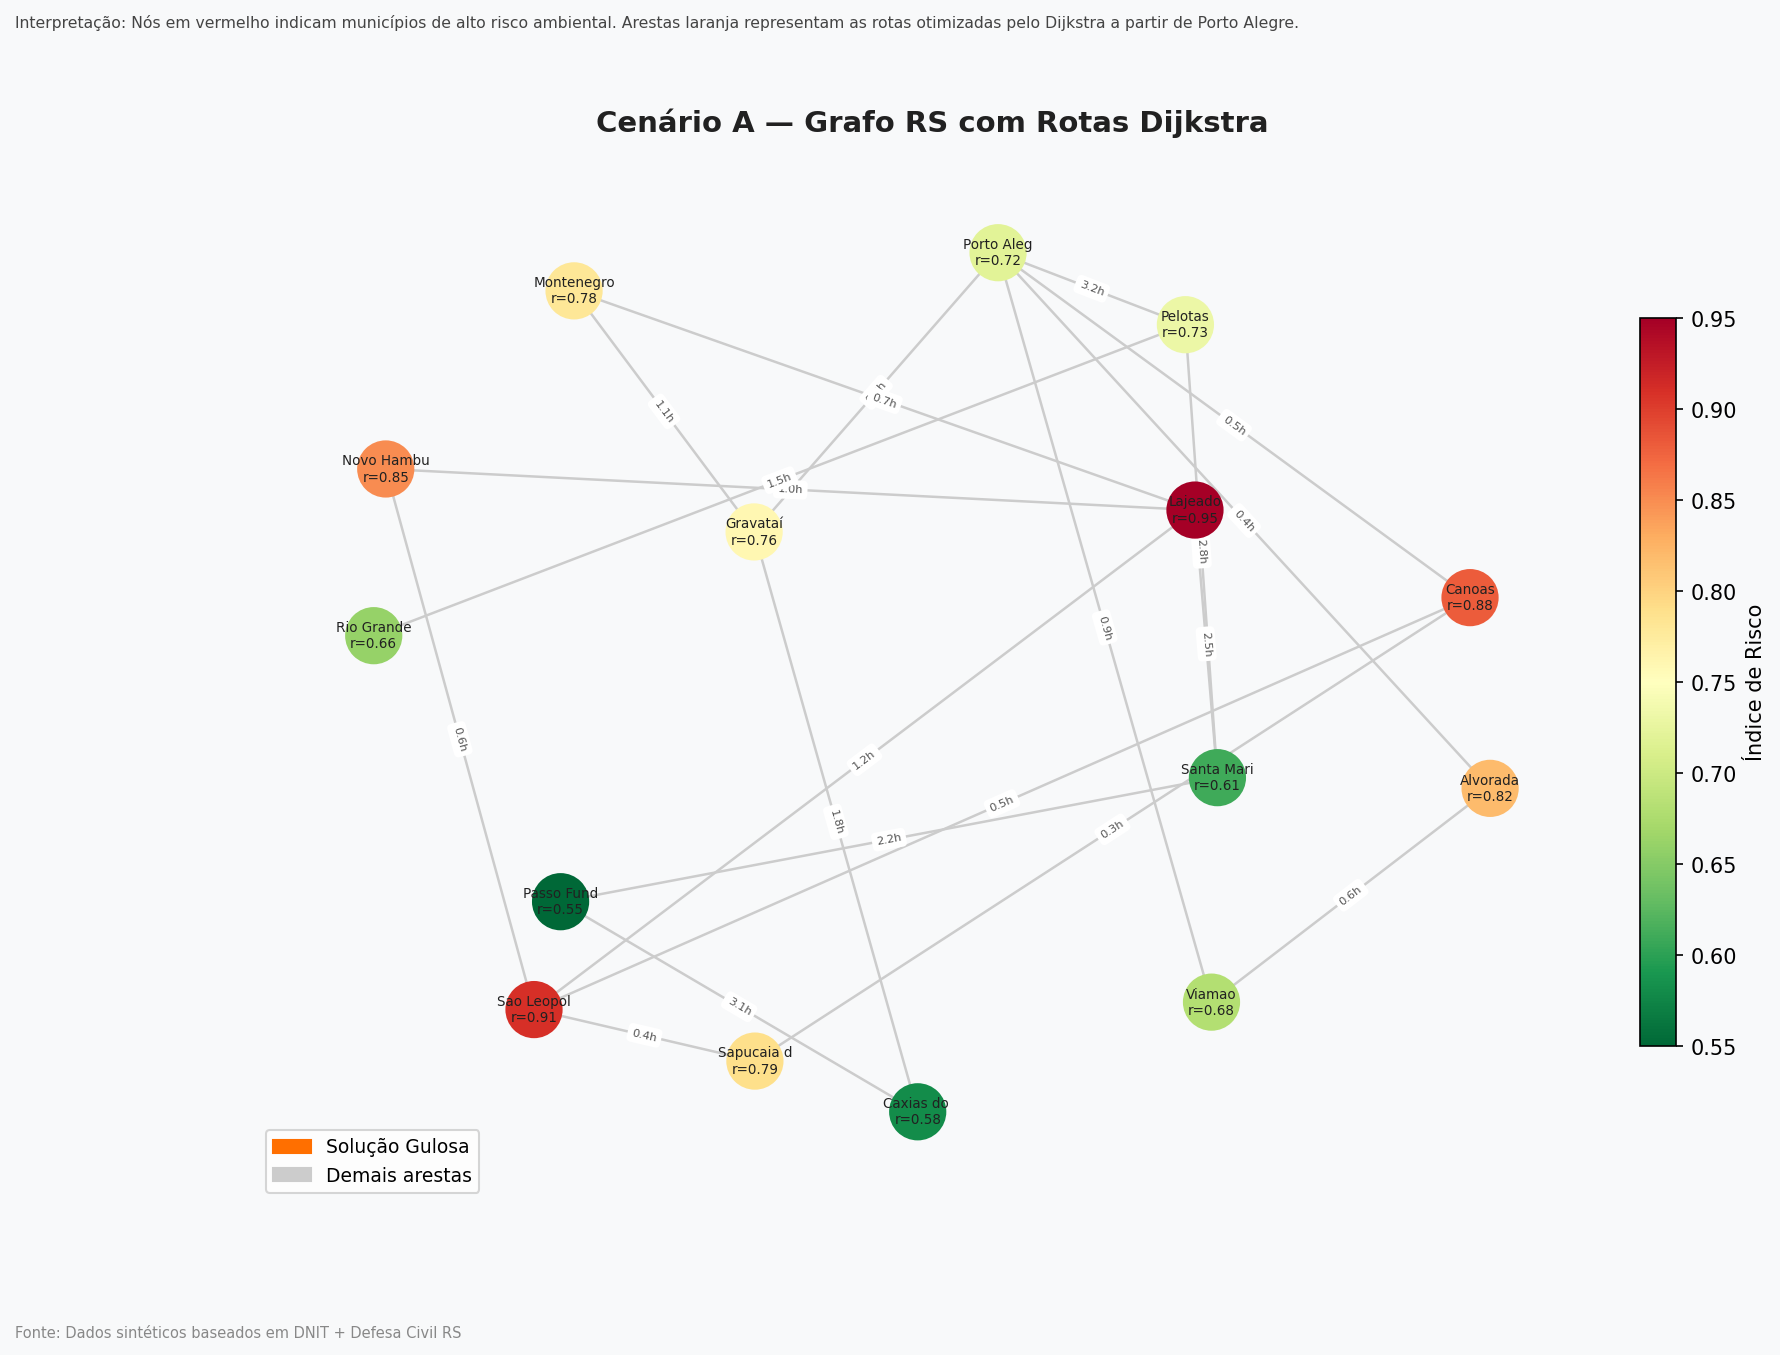

In [4]:
# Visualização do grafo RS
fig_path = plotar_grafo(g_rs, res, titulo='Cenário A — Grafo RS com Rotas Dijkstra',
                        caminho_salvar='../output_figs/nb_fig1_rs.png')
from IPython.display import Image
Image(fig_path)

## 2. BST — Diagrama de Municípios por Risco

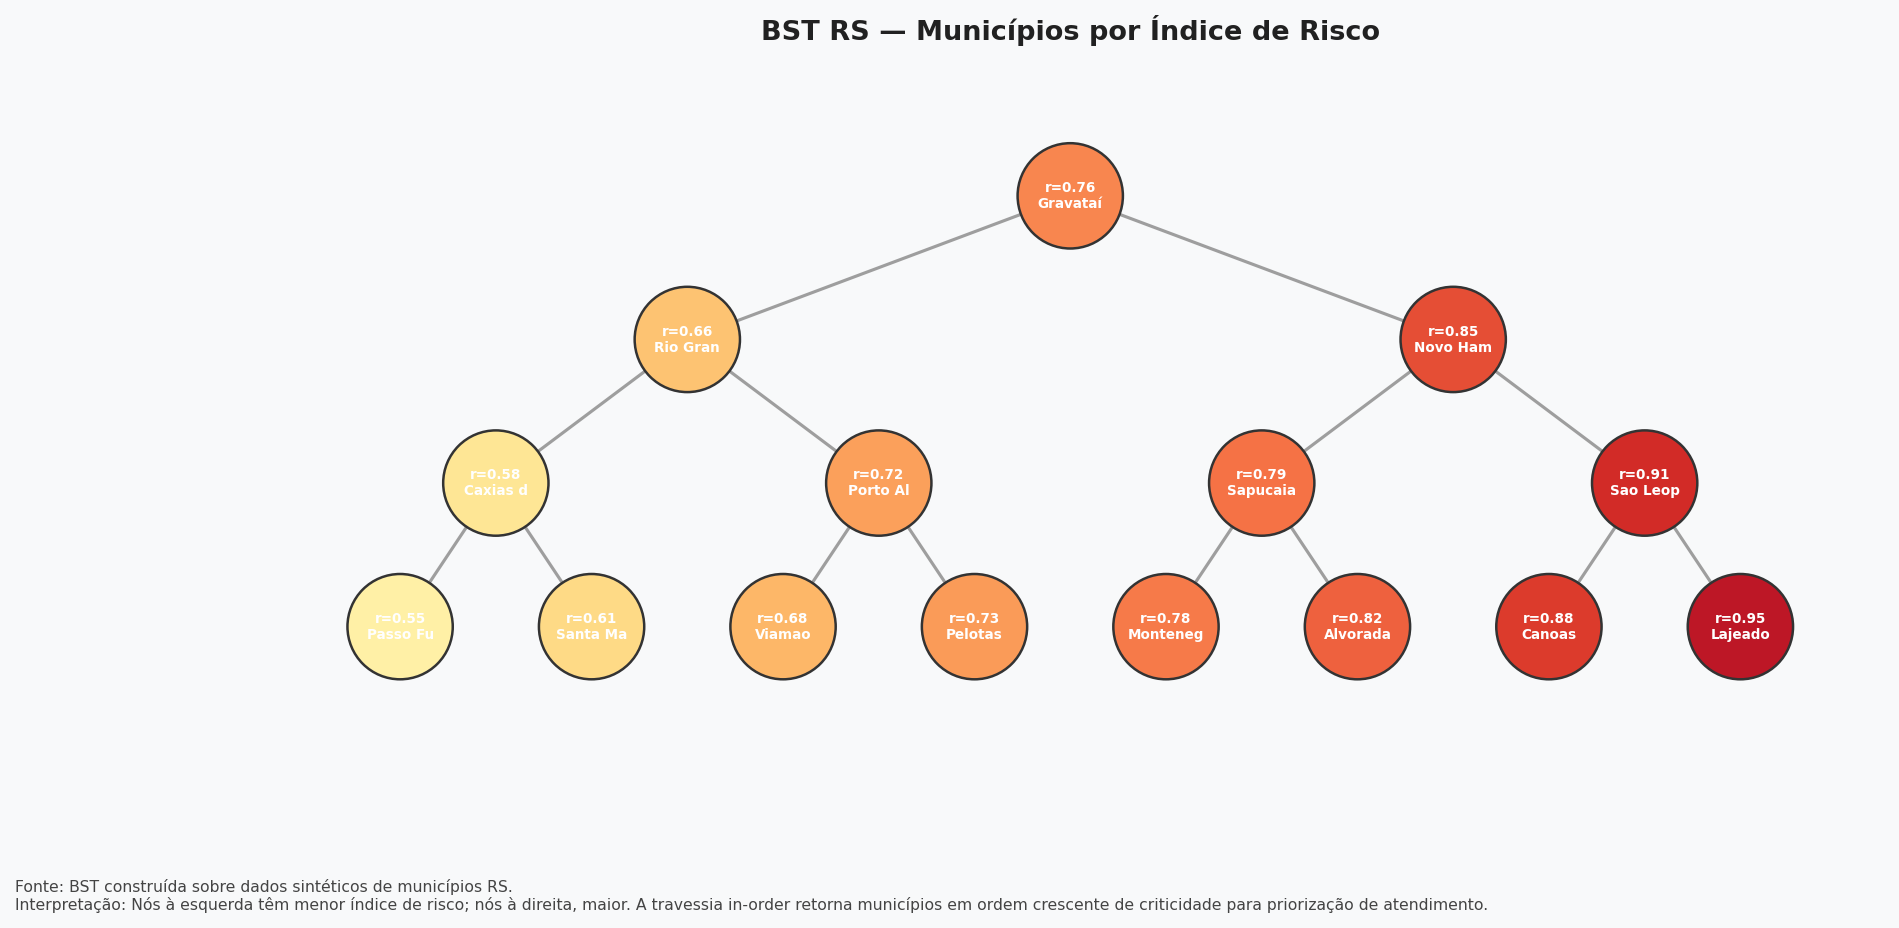

In [5]:
fig_path = plotar_bst(bst_rs, titulo='BST RS — Municípios por Índice de Risco',
                      caminho_salvar='../output_figs/nb_fig2_bst.png')
from IPython.display import Image
Image(fig_path)

## 3. Cenário B — MATOPIBA

In [6]:
g_mt = Grafo.from_json('../data/raw/municipios_matopiba.json')
bst_mt = BinarySearchTree.from_grafo(g_mt)

# Kruskal para cobertura mínima
res_k = kruskal(g_mt)
print(f'MST Kruskal MATOPIBA: custo={res_k.custo_total:.2f}h, arestas={len(res_k.arestas_mst)}')
print('Arestas da MST:')
for u, v, p in sorted(res_k.arestas_mst, key=lambda x: x[2]):
    nu = g_mt.get_vertice(u)[1]
    nv = g_mt.get_vertice(v)[1]
    print(f'  {nu:<28} ↔ {nv:<28} peso={p:.2f}h')

MST Kruskal MATOPIBA: custo=22.00h, arestas=9
Arestas da MST:
  Luis Eduardo Magalhaes       ↔ Barreiras                    peso=1.20h
  Picos                        ↔ Uruçui                       peso=1.50h
  Luis Eduardo Magalhaes       ↔ Formosa do Rio Preto         peso=1.80h
  Palmas                       ↔ Araguaina                    peso=2.10h
  Araguaina                    ↔ Imperatriz                   peso=2.80h
  Balsas                       ↔ Luis Eduardo Magalhaes       peso=2.80h
  Balsas                       ↔ Uruçui                       peso=3.10h
  Picos                        ↔ Timon                        peso=3.20h
  Balsas                       ↔ Imperatriz                   peso=3.50h


## 4. Análise de Desempenho — Força Bruta vs Dijkstra

In [7]:
monitor = PerformanceMonitor()
meds_fb   = monitor.benchmark_forca_bruta([5,6,7,8,9,10,11,12], repeticoes=3)
meds_dijk = monitor.benchmark_dijkstra([5,8,10,12,20,50,100], repeticoes=3)
print(monitor.tabela_resumo())

Algoritmo           N    Tempo(ms)    Mem(MB)        Ops        Custo
--------------------------------------------------------------------
Dijkstra            5       0.0481   0.002230          9        22.49
Dijkstra            8       0.0525   0.002571         15        58.49
Dijkstra           10       0.0604   0.002716         20        94.86
Dijkstra           12       0.0755   0.003662         25       101.25
Dijkstra           20       0.0956   0.005287         41       308.16
Dijkstra           50       0.1698   0.011709        110       843.60
Dijkstra          100       0.3550   0.026619        215      1877.10
Forca Bruta         5       0.0488   0.001640          5         5.21
Forca Bruta         6       0.0629   0.001704          6         3.77
Forca Bruta         7       0.0363   0.001732          8         7.99
Forca Bruta         8       0.0665   0.001867          9         8.17
Forca Bruta         9       0.1133   0.002383         21        12.07
Forca Bruta        10

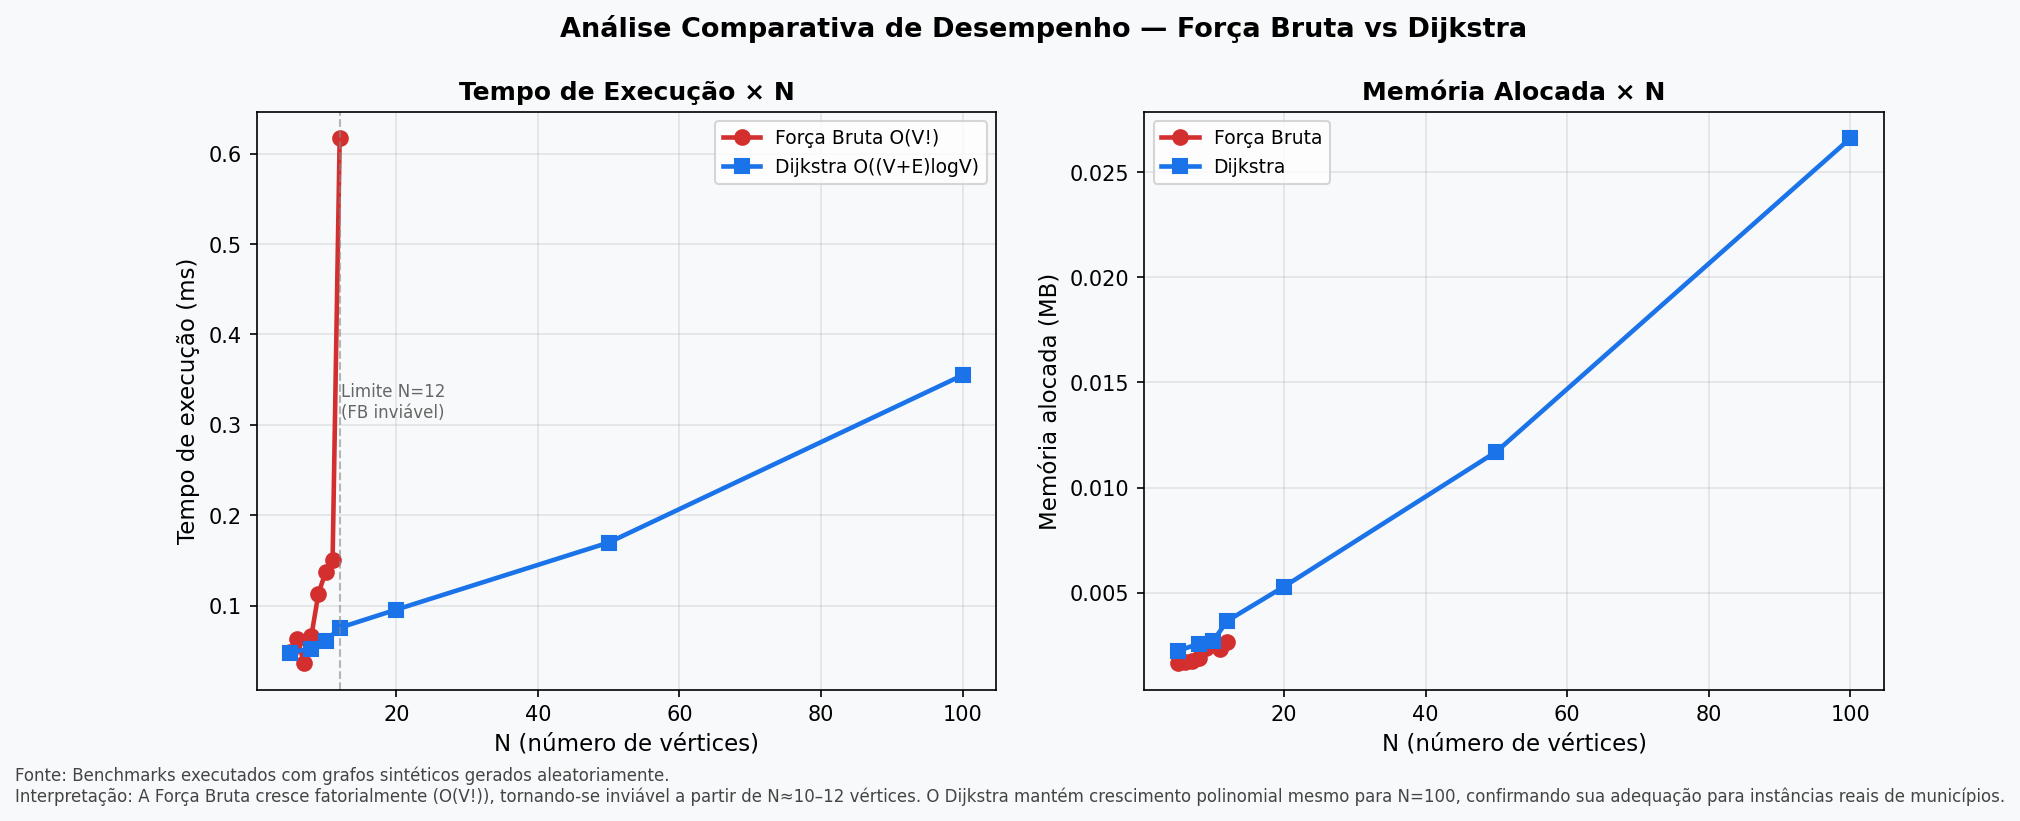

In [8]:
fig_path = plotar_desempenho(meds_fb, meds_dijk,
                              caminho_salvar='../output_figs/nb_fig3_desempenho.png')
Image(fig_path)

## 5. Gap de Otimalidade

Gap Dijkstra vs Força Bruta:
  N= 5: 0.0000%  ░
  N= 6: 0.0000%  ░
  N= 7: 0.0000%  ░
  N= 8: 0.0000%  ░
  N= 9: 0.0000%  ░
  N=10: 0.0000%  ░


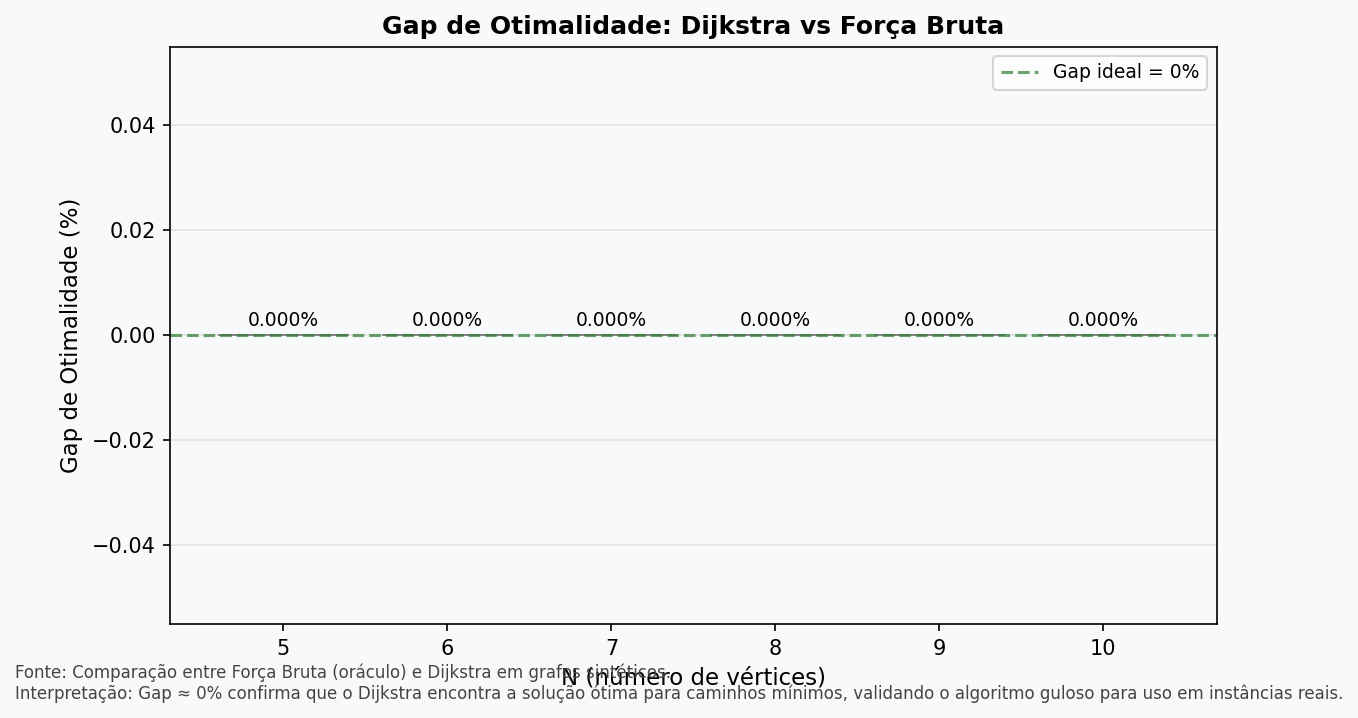

In [9]:
gaps = monitor.calcular_gap_otimalidade([5,6,7,8,9,10])
print('Gap Dijkstra vs Força Bruta:')
for n, g in sorted(gaps.items()):
    barra = '█' * int(g * 10) if g > 0 else '░'
    print(f'  N={n:2d}: {g:.4f}%  {barra}')

fig_path = plotar_gap_otimalidade(gaps, caminho_salvar='../output_figs/nb_fig4_gap.png')
Image(fig_path)

## 6. Explosão Combinatória — Força Bruta

In [10]:
import numpy as np
explosao = dados_explosao_combinatoria(list(range(3, 16)))
ns = list(explosao.keys())
cs = list(explosao.values())

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(ns, cs, 'o-', color='#d32f2f', linewidth=2.2, markersize=8)
ax.axvline(x=12, color='#888', linestyle='--', alpha=0.6)
ax.text(12.2, max(cs)*0.3, 'N=12\n(limite prático)', fontsize=9, color='#555')
ax.set_xlabel('N (vértices)', fontsize=11)
ax.set_ylabel('Caminhos possíveis (escala log)', fontsize=11)
ax.set_title('Explosão Combinatória da Força Bruta', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../output_figs/nb_explosao_combinatoria.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figura salva!')

Figura salva!


## 7. Escala de Decisão

| Nível | Solução | Qualidade | Custo Comp. | Aplicabilidade |
|-------|---------|-----------|-------------|----------------|
| **1 — Ótimo** | Força Bruta (N≤8) | 100% (global) | O(V!) — inviável N>12 | Validação e testes |
| **2 — Excelente** | Dijkstra + BST (N≤500) | ~100% (gap=0%) | O((V+E)logV) | Cenários reais |
| **3 — Bom** | Dijkstra sem BST | ~100% (gap=0%) | O((V+E)logV) | Sem priorização |
| **4 — Aceitável** | Prim/Kruskal (MST) | Ótimo p/ cobertura | O((V+E)logV) | Cobertura mínima |

**Recomendação prática:** Para o contexto da Defesa Civil RS (N~478 municípios),
o **Dijkstra integrado com a BST** (Nível 2) é a solução recomendada: garante otimalidade
com tempo de resposta em milissegundos, priorizando automaticamente municípios de alto risco.

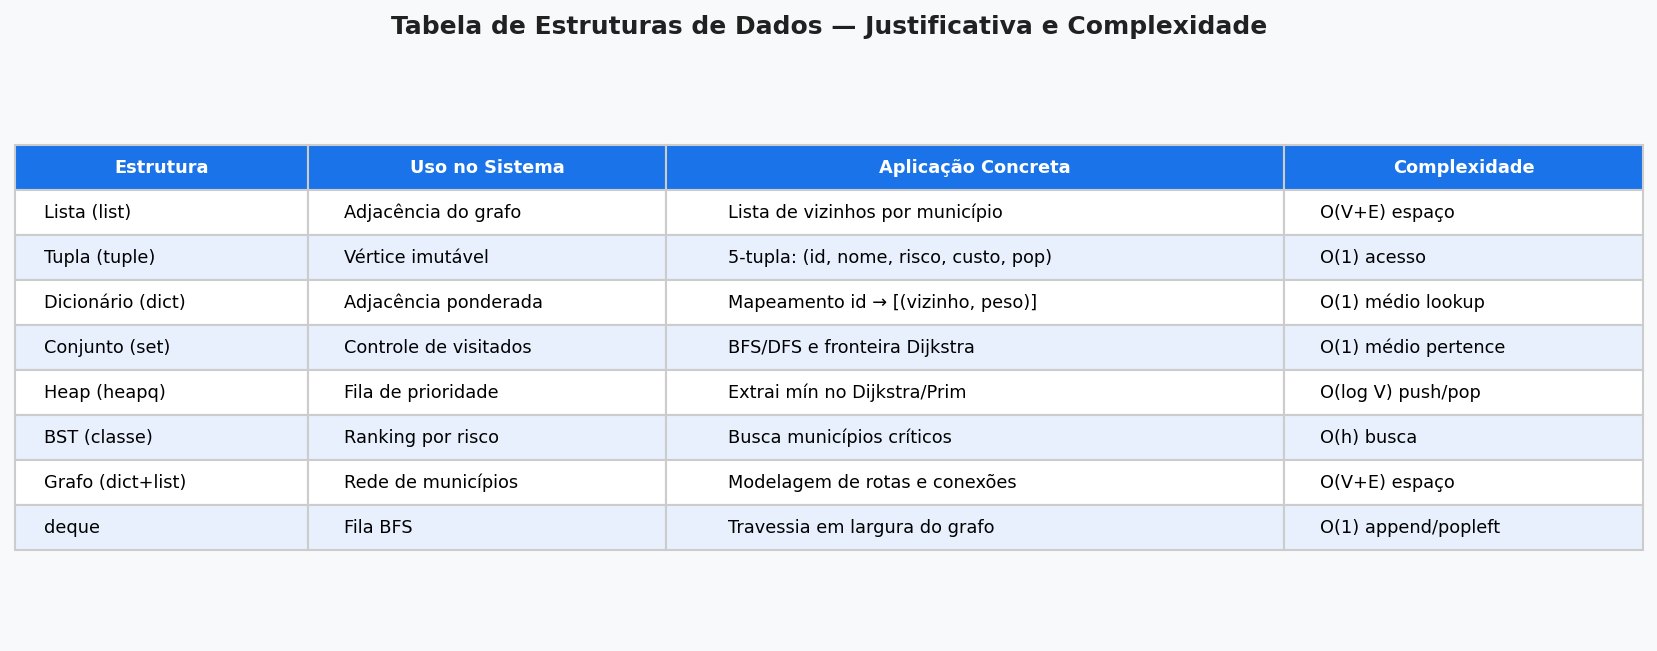

In [11]:
# Tabela de estruturas de dados
fig_path = plotar_tabela_estruturas(caminho_salvar='../output_figs/nb_fig5_tabela.png')
Image(fig_path)